# 🌲 Day 5 Exercise: KNN + Customer Segmentation

**Time required:** 90–120 minutes  
**Part A (30 min):**  KNN on the Wine dataset Part B (60 min): K-Means customer segmentation from scratch

### Part A: KNN Classification in Wine Dataset

In [2]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine, make_blobs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, silhouette_score,
                              silhouette_samples)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

# load wine dataset
# 178 wines, 13 chemical properties, 3 wine types (classes 0, 1, 2)
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target)

print("Shape:", X.shape)
print(f"Classes: {wine.target_names}")
print(f"Class distribution:\n{y.value_counts().to_string()}")
print(f"\nFeature ranges (shows why scaling is essential):")
print(X.describe().loc[['min','max']].round(2))

Shape: (178, 13)
Classes: ['class_0' 'class_1' 'class_2']
Class distribution:
1    71
0    59
2    48

Feature ranges (shows why scaling is essential):
     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
min    11.03        0.74  1.36               10.6       70.0           0.98   
max    14.83        5.80  3.23               30.0      162.0           3.88   

     flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
min        0.34                  0.13             0.41             1.28  0.48   
max        5.08                  0.66             3.58            13.00  1.71   

     od280/od315_of_diluted_wines  proline  
min                          1.27    278.0  
max                          4.00   1680.0  


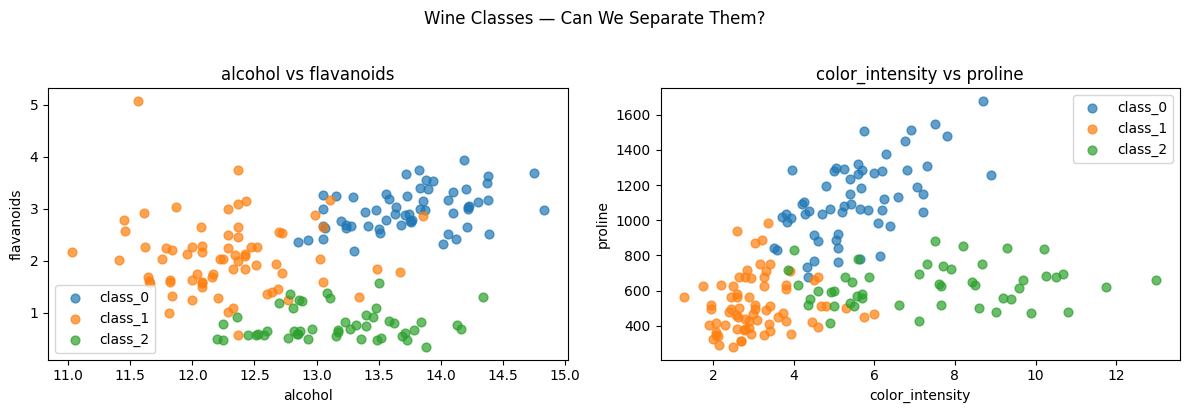

In [3]:
# Quick EDA: are classes are separable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Two most important features (based on prior domain knowledge)
for ax, (f1, f2) in zip(axes, [
    ('alcohol', 'flavanoids'),
    ('color_intensity', 'proline')
]):
    for i, name in enumerate(wine.target_names):
        mask = y == i
        ax.scatter(X[f1][mask], X[f2][mask], label=name, alpha=0.7, s=40)
    ax.set_xlabel(f1)
    ax.set_ylabel(f2)
    ax.set_title(f'{f1} vs {f2}')
    ax.legend()

plt.suptitle('Wine Classes — Can We Separate Them?', y=1.02)
plt.tight_layout()
plt.show()

In [5]:
# KNN without Scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
acc_unscaled = knn_unscaled.score(X_test, y_test)
print(f"KNN (K=5) WITHOUT scaling: {acc_unscaled:.1%}")

KNN (K=5) WITHOUT scaling: 80.6%


##### Find Optimal K with Cross-Validation

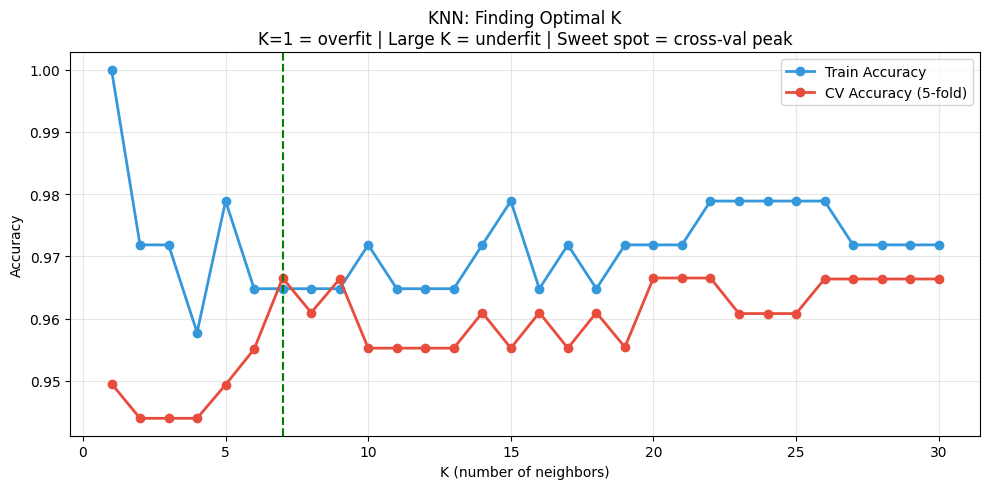


Best K = 7 with CV accuracy = 96.7%


In [6]:
k_values = range(1, 31)
cv_scores = []
train_scores = []

pipe_base = Pipeline([('scaler', StandardScaler()),
                       ('knn', KNeighborsClassifier())])

for k in k_values:
    pipe_base.set_params(knn__n_neighbors=k)
    scores = cross_val_score(pipe_base, X, y, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

    pipe_base.fit(X_train, y_train)
    train_scores.append(pipe_base.score(X_train, y_train))

plt.figure(figsize=(10, 5))
plt.plot(k_values, train_scores, 'o-', color='#3498db',
         label='Train Accuracy', linewidth=2)
plt.plot(k_values, cv_scores, 'o-', color='#e74c3c',
         label='CV Accuracy (5-fold)', linewidth=2)
plt.xlabel('K (number of neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN: Finding Optimal K\n'
          'K=1 = overfit | Large K = underfit | Sweet spot = cross-val peak')
plt.legend()
plt.grid(alpha=0.3)
plt.axvline(x=cv_scores.index(max(cv_scores))+1, color='green',
            linestyle='--', label=f'Best K={cv_scores.index(max(cv_scores))+1}')
plt.tight_layout()
plt.show()

best_k = cv_scores.index(max(cv_scores)) + 1
print(f"\nBest K = {best_k} with CV accuracy = {max(cv_scores):.1%}")

##### Final KKN Model with Best K

In [7]:
best_knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k))
])
best_knn_pipe.fit(X_train, y_train)
pred = best_knn_pipe.predict(X_test)

print(f"\nFinal KNN (K={best_k}) Results:")
print(classification_report(y_test, pred, target_names=wine.target_names))

print("\n=== SCALING IMPACT SUMMARY ===")
print(f"  Without scaling (K=5):              {acc_unscaled:.1%}")
print(f"  With scaling (optimal K={best_k}): {best_knn_pipe.score(X_test, y_test):.1%}")


Final KNN (K=7) Results:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36


=== SCALING IMPACT SUMMARY ===
  Without scaling (K=5):              80.6%
  With scaling (optimal K=7): 100.0%


### PART B: K-Means Customer Segmentation (Real Business Project)
##### This is the most practically valuable exercise this week. Companies pay data scientists significant salaries to do exactly this.
##### Scenario: You work at an e-commerce company. The marketing team has customer data — annual income and spending score — and wants to know: "Who are our distinct customer groups so we can target them differently?"

In [8]:
# Create realistic customer dataset
# Simulating a real retail customer dataset
np.random.seed(42)
n = 300

# Manually create 5 realistic customer segments
segments = {
    'Budget Savers':       {'income': (20, 35),  'spending': (5, 30),   'n': 60},
    'Careful Earners':     {'income': (55, 75),  'spending': (10, 35),  'n': 60},
    'Impulse Buyers':      {'income': (15, 40),  'spending': (65, 95),  'n': 60},
    'Premium Loyalists':   {'income': (70, 100), 'spending': (70, 99),  'n': 60},
    'Average Customers':   {'income': (40, 70),  'spending': (40, 65),  'n': 60},
}

data_parts = []
true_labels = []
for i, (seg_name, params) in enumerate(segments.items()):
    inc = np.random.uniform(*params['income'], params['n'])
    spen = np.random.uniform(*params['spending'], params['n'])
    data_parts.append(np.column_stack([inc, spen]))
    true_labels.extend([i] * params['n'])

customer_data = np.vstack(data_parts)
df_customers = pd.DataFrame(customer_data,
                             columns=['Annual_Income_k', 'Spending_Score'])
df_customers['CustomerID'] = range(1, len(df_customers) + 1)

print("Customer dataset shape:", df_customers.shape)
print(df_customers.describe().round(1))

Customer dataset shape: (300, 3)
       Annual_Income_k  Spending_Score  CustomerID
count            300.0           300.0       300.0
mean              52.8            51.0       150.5
std               23.6            28.9        86.7
min               15.4             5.1         1.0
25%               30.2            24.2        75.8
50%               56.4            52.1       150.5
75%               69.6            78.1       225.2
max               99.7            98.8       300.0


##### Visualize Raw Data

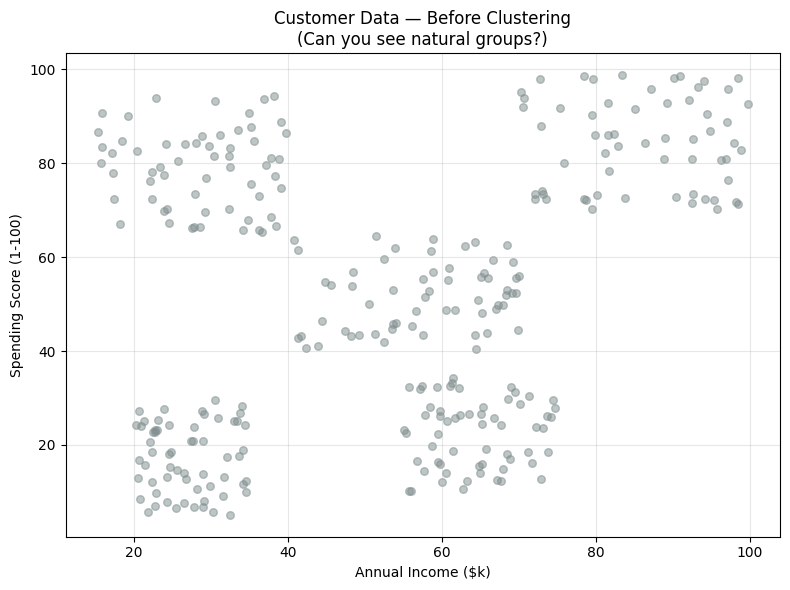

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(df_customers['Annual_Income_k'],
            df_customers['Spending_Score'],
            alpha=0.5, color='#7f8c8d', s=30)
plt.xlabel('Annual Income ($k)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Data — Before Clustering\n'
          '(Can you see natural groups?)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##### The Elbow Method: Find the Right K

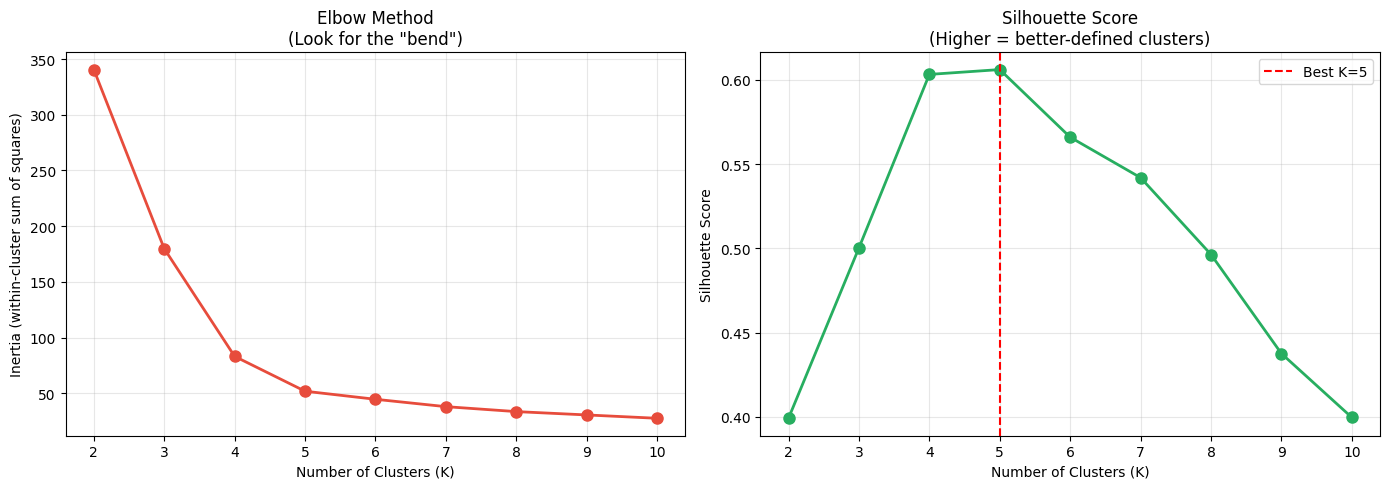


Elbow method suggests: look for the bend
Silhouette method suggests: K = 5 (score = 0.606)


In [10]:
X_cust = df_customers[['Annual_Income_k', 'Spending_Score']].values
scaler = StandardScaler()
X_cust_scaled = scaler.fit_transform(X_cust)

inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cust_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_cust_scaled, km.labels_)
    silhouette_scores.append(sil)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, inertias, 'o-', color='#e74c3c', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('Elbow Method\n(Look for the "bend")')
axes[0].grid(alpha=0.3)

# Silhouette plot
axes[1].plot(K_range, silhouette_scores, 'o-', color='#27ae60', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score\n(Higher = better-defined clusters)')
axes[1].grid(alpha=0.3)

best_k_sil = list(K_range)[silhouette_scores.index(max(silhouette_scores))]
axes[1].axvline(x=best_k_sil, color='red', linestyle='--',
                label=f'Best K={best_k_sil}')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nElbow method suggests: look for the bend")
print(f"Silhouette method suggests: K = {best_k_sil} "
      f"(score = {max(silhouette_scores):.3f})")

##### Fit Final K-Means Model

ValueError: Unrecognized marker style '★'

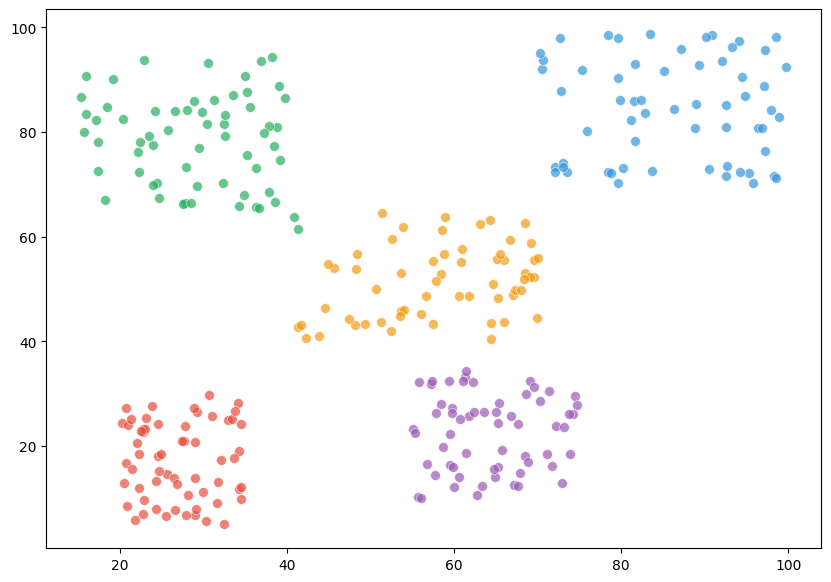

In [11]:
optimal_k = best_k_sil  # use silhouette recommendation

km_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
km_final.fit(X_cust_scaled)

df_customers['Cluster'] = km_final.labels_

# ── Visualize the Discovered Segments ────────────────────────
colors_palette = ['#e74c3c', '#3498db', '#27ae60', '#f39c12', '#9b59b6',
                   '#1abc9c', '#e67e22', '#34495e']
cluster_names = [f'Segment {i}' for i in range(optimal_k)]

fig, ax = plt.subplots(figsize=(10, 7))
for i in range(optimal_k):
    mask = df_customers['Cluster'] == i
    ax.scatter(df_customers[mask]['Annual_Income_k'],
               df_customers[mask]['Spending_Score'],
               color=colors_palette[i], label=cluster_names[i],
               alpha=0.7, s=50, edgecolors='white', linewidth=0.5)

# Plot centroids (un-scaled back to original scale)
centroids_original = scaler.inverse_transform(km_final.cluster_centers_)
ax.scatter(centroids_original[:, 0], centroids_original[:, 1],
           s=250, marker='★', color='black', zorder=5, label='Centroids')

ax.set_xlabel('Annual Income ($k)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_title(f'Customer Segmentation — {optimal_k} Discovered Segments\n'
             '(No labels were used — the model found these groups)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

##### Profile each segment — the business deliverable

In [12]:
print("=" * 60)
print("CUSTOMER SEGMENT PROFILES")
print("=" * 60)

segment_profile = df_customers.groupby('Cluster').agg(
    Count=('CustomerID', 'count'),
    Avg_Income=('Annual_Income_k', 'mean'),
    Avg_Spending=('Spending_Score', 'mean')
).round(1)

# Add business interpretation
business_names = {
    0: 'To be determined',
    1: 'To be determined',
    2: 'To be determined',
    3: 'To be determined',
    4: 'To be determined',
}

print(segment_profile)
print()
print("Business Interpretation Guide:")
print("  High income + High spending  → Premium / VIP customers")
print("  High income + Low spending   → Careful / Conservative earners")
print("  Low income  + High spending  → Impulsive / Credit-reliant buyers")
print("  Low income  + Low spending   → Budget-conscious shoppers")
print("  Mid income  + Mid spending   → Average / Typical customers")
print()
print("Marketing actions per segment:")
print("  Premium:      Loyalty programs, exclusive early access")
print("  Careful:      Value demonstration, ROI messaging")
print("  Impulsive:    Flash sales, urgency campaigns")
print("  Budget:       Discounts, bulk-buy deals")
print("  Average:      Standard campaigns, upselling")

CUSTOMER SEGMENT PROFILES
         Count  Avg_Income  Avg_Spending
Cluster                                 
0           60        27.0          17.2
1           60        86.1          84.4
2           62        29.3          78.4
3           58        58.2          51.4
4           60        64.2          22.6

Business Interpretation Guide:
  High income + High spending  → Premium / VIP customers
  High income + Low spending   → Careful / Conservative earners
  Low income  + High spending  → Impulsive / Credit-reliant buyers
  Low income  + Low spending   → Budget-conscious shoppers
  Mid income  + Mid spending   → Average / Typical customers

Marketing actions per segment:
  Premium:      Loyalty programs, exclusive early access
  Careful:      Value demonstration, ROI messaging
  Impulsive:    Flash sales, urgency campaigns
  Budget:       Discounts, bulk-buy deals
  Average:      Standard campaigns, upselling


##### Predict segment for a NEW customer

In [13]:
def predict_customer_segment(income, spending, model, scaler, profile):
    new_customer = np.array([[income, spending]])
    new_scaled = scaler.transform(new_customer)
    cluster = model.predict(new_scaled)[0]
    avg_income = profile.loc[cluster, 'Avg_Income']
    avg_spending = profile.loc[cluster, 'Avg_Spending']
    print(f"New customer: ${income}k income, {spending} spending score")
    print(f"  → Assigned to Segment {cluster}")
    print(f"  → Segment avg: ${avg_income:.0f}k income, {avg_spending:.0f} spending")
    return cluster

print("=== PREDICTING NEW CUSTOMER SEGMENTS ===\n")
predict_customer_segment(85, 90, km_final, scaler, segment_profile)
print()
predict_customer_segment(25, 15, km_final, scaler, segment_profile)
print()
predict_customer_segment(60, 50, km_final, scaler, segment_profile)

=== PREDICTING NEW CUSTOMER SEGMENTS ===

New customer: $85k income, 90 spending score
  → Assigned to Segment 1
  → Segment avg: $86k income, 84 spending

New customer: $25k income, 15 spending score
  → Assigned to Segment 0
  → Segment avg: $27k income, 17 spending

New customer: $60k income, 50 spending score
  → Assigned to Segment 3
  → Segment avg: $58k income, 51 spending


3